# TPI 2: Text Mining y análisis discursivo comparado

**Modalidad:** Trabajo Práctico Integrador en duplas.

**Formato:** notebook individual de la dupla + corpus estructurado en `csv` o `jsonl`.

**Escala del corpus:** entre 6 y 10 textos, distribuidos en **dos grupos comparables**.

**Desafío general**
En este trabajo van a construir un análisis discursivo comparado sobre un corpus pequeño y situado. El objetivo no es automatizar la interpretación ni reemplazar la lectura, sino usar herramientas de `spaCy`, `Bag of Words`, `TF-IDF`, bigramas y visualización para producir observables, contrastar series y volver a fragmentos concretos del corpus.

**Resolución con IA, bajo responsabilidad humana**
Pueden trabajar con asistencia de IA para destrabar errores, auditar código, discutir visualizaciones o revisar redacción. La IA no reemplaza el criterio analítico de la dupla. Toda decisión metodológica, toda interpretación y toda versión entregada quedan bajo su responsabilidad.


### Registro breve de trabajo con IA

Completen al menos una entrada por bloque importante del trabajo.

| Bloque | Objetivo de la consulta | Prompt o pedido a la IA | Qué respondió (resumen) | Qué conservaron y por qué | Qué descartaron y por qué |
|---|---|---|---|---|---|
| Definición del corpus | | | | | |
| Procesamiento con spaCy | | | | | |
| Representaciones sparse | | | | | |
| Visualización | | | | | |
| Interpretación final | | | | | |


### Registro breve de trabajo con IA

| Bloque | Objetivo de la consulta | Prompt o pedido a la IA | Qué respondió (resumen) | Qué conservaron y por qué | Qué descartaron y por qué |
|---|---|---|---|---|---|
| Definición del corpus | Definir una comparación válida y estructurar el dataset | "Quiero hacer una comparación medio vs medio con noticias sobre inflación, ¿cómo armo el corpus?" | Sugirió elegir dos medios con líneas editoriales distintas, mantener consistencia temática y estructurar un archivo JSONL con una noticia por línea | Se conservó la estructura del corpus y la elección de medios (La Nación vs C5N) porque permite una comparación clara | Se descartó ampliar demasiado el corpus por una cuestión de tiempo y alcance del TP |
| Procesamiento con spaCy | Evaluar cómo limpiar y procesar el texto | "¿Cómo hago preprocesamiento de texto para análisis?" | Propuso tokenización, eliminación de stopwords y normalización del texto | Se tomó como referencia conceptual para entender el proceso | Se descartó implementarlo completamente porque los resultados no mejoraban significativamente la interpretación en este corpus |
| Representaciones sparse | Aplicar Bag of Words y TF-IDF correctamente | "¿Cómo comparo BOW y TF-IDF en un dataset?" | Explicó cómo construir ambas representaciones y la diferencia conceptual entre frecuencia y relevancia | Se utilizó tanto el código como la explicación conceptual para el análisis comparativo | No se descartó contenido relevante en este bloque |
| Visualización | Generar gráficos claros para comparar resultados | "¿Cómo hago gráficos de palabras más frecuentes?" | Sugirió gráficos de barras con matplotlib y nubes de palabras | Se utilizaron gráficos de frecuencias por medio porque permiten visualizar diferencias rápidamente | Se descartaron visualizaciones más complejas por no aportar claridad adicional |
| Interpretación final | Redactar conclusiones e interpretar resultados | "¿Cómo redacto la conclusión del análisis?" | Propuso una estructura comparativa entre medios destacando diferencias discursivas | Se tomó la estructura base y se adaptó al contenido del análisis propio | Se descartaron formulaciones demasiado genéricas para mantener coherencia con los resultados obtenidos |

## 0. Qué tienen que entregar

La entrega mínima incluye:

- este notebook completo y ejecutable;
- un archivo `csv` o `jsonl` con el corpus usado;
- una columna `grupo_comparacion` con exactamente dos valores posibles;
- al menos dos visualizaciones analíticas bien rotuladas;
- una comparación entre `Bag of Words` y `TF-IDF`;
- al menos tres fragmentos comentados para la vuelta a la lectura cercana;
- una conclusión interpretativa y una sección de límites del método.

Si el corpus no está bien estructurado o si el trabajo se limita a listar frecuencias sin interpretar, la entrega queda incompleta.


## 1. Condiciones del corpus

La comparación es **obligatoria**. Elijan una de estas rutas:

1. **Medio vs. medio**
   - Ejemplo: cómo abordan la IA `Cenital` y `Anfibia`.
2. **Columnista vs. columnista**
   - Ejemplo: dos autoras o autores que escriben sobre una misma temática.
3. **Mismo columnista en contextos distintos**
   - Ejemplo: mismo autor en dos medios o en dos formatos diferentes.
4. **Podcast vs. podcast** o **serie vs. serie**
   - Permitido, pero más exigente por la calidad de la transcripción y la limpieza del texto.

**Restricciones obligatorias**

- El corpus debe tener entre 6 y 10 textos.
- Tiene que haber exactamente **dos grupos comparables**.
- La temática debe ser consistente y estar justificada.
- No usen embeddings, vectores densos ni LLMs como sustituto del análisis.
- La variable de contraste debe estar escrita en la columna `grupo_comparacion`.

**Columnas mínimas esperadas**

- `id`
- `fecha`
- `medio`
- `autor`
- `titulo`
- `texto`
- `grupo_comparacion`


In [ ]:
# NO EJECUTAR ESTE CÓDIGOS, SÓLO ES PARA MOSTRAR EL PROCESO DE SCRAPING DE LOS ARTÍCULOS

import requests
from bs4 import BeautifulSoup

urls_lanacion = [
      "https://www.lanacion.com.ar/lnmas/juan-carlos-de-pablo-analizo-la-inflacion-de-marzo-y-advirtio-por-un-dato-ausente-que-puede-impactar-nid14042026/",
    "https://www.lanacion.com.ar/economia/la-inflacion-mayorista-dio-un-salto-en-marzo-y-cerro-en-34-nid16042026/",
    "https://www.lanacion.com.ar/economia/sin-contar-carne-combustibles-y-tarifas-la-inflacion-igual-acelero-y-encontro-un-nuevo-piso-nid20042026/",
    "https://www.lanacion.com.ar/economia/juan-carlos-de-pablo-opino-sobre-la-inflacion-de-marzo-y-explico-en-detalle-el-impacto-de-la-guerra-nid15042026/"
]

textos_lanacion = []

for url in urls_lanacion:
    r = requests.get(url)
    soup = BeautifulSoup(r.text, "html.parser")
    paragraphs = soup.find_all("p")
    text = " ".join(p.get_text() for p in paragraphs)
    textos_lanacion.append(text)

urls_pagina12 = [
    "https://www.pagina12.com.ar/2026/04/14/la-inflacion-de-marzo-fue-34-por-ciento-segun-el-indec/",
    "https://www.pagina12.com.ar/2026/04/15/milei-con-la-brujula-rota-no-es-inflacion-es-un-salto-de-precios/",
    "https://www.pagina12.com.ar/2026/04/06/cuanto-por-encima-del-3-por-ciento/",
    "https://www.pagina12.com.ar/2026/04/14/la-eterna-promesa-de-milei-tarde-o-temprano-las-cosas-van-a-empezar-a-funcionar/"
]

textos_pagina12 = []

for url in urls_pagina12:
    r = requests.get(url)
    soup = BeautifulSoup(r.text, "html.parser")
    paragraphs = soup.find_all("p")
    text = " ".join(p.get_text() for p in paragraphs)
    textos_pagina12.append(text)

In [ ]:
# NO EJECUTAR, YA QUE SOBREESCRIBE JSON YA CREADO

import json

with open("corpus_tpi2.jsonl", "w", encoding="utf-8") as f:
    
    for t in textos_lanacion:
        obj = {"medio": "LaNacion", "texto": t}
        f.write(json.dumps(obj, ensure_ascii=False) + "\n")
    
    for t in textos_pagina12:
        obj = {"medio": "Pagina12", "texto": t}
        f.write(json.dumps(obj, ensure_ascii=False) + "\n")

In [42]:
import pandas as pd

df = pd.read_json("corpus_final.jsonl", lines=True)

In [43]:
df.head()

,medio,texto,grupo_comparacion,id,titulo,fecha,autor
0,LaNacion,"Después de conocerse la inflación de marzo, que fue de 3,4%, el economista Juan Carlos de Pablo analizó el dato y las variables que expl...",LaNacion,1,Juan Carlos de Pablo analizó la inflación de marzo y advirtió por un dato “ausente” que puede impactar en los próximos meses,2026-04-17,La Nacion
1,LaNacion,"Luego de haber registrado en febrero el nivel más bajo desde mayo de 2025, la inflación mayorista dio un salto en marzo y cerró en 3,4% ...",LaNacion,2,"La inflación mayorista dio un salto en marzo y cerró en 3,4%",2026-04-16,Carlos Manzoni
2,LaNacion,"La inflación de marzo, del 3,4%, dejó un mensaje incluso más incómodo para el Gobierno que el impacto transitorio de la guerra en Medio ...",LaNacion,3,"Sin carne, combustibles y tarifas, la inflación igual aceleró y encontró un nuevo piso",2026-04-21,Agustin Maza
3,LaNacion,"La medición del índice de precios al consumidor del tercer mes del año arrojó una suba superior a los registros previos de 3,4%. En este...",LaNacion,4,Juan Carlos de Pablo opinó sobre la inflación de marzo y explicó en detalle el impacto de la guerra de Medio Oriente en los precios,2026-04-15,La Nacion
4,Pagina12,"El Instituto Nacional de Estadística y Censos (INDEC) dio a conocer que la inflación de marzo fue de 3,4. De esta manera, el Índice de P...",Pagina12,5,"La inflación de marzo fue de 3,4 segun el INDEC",2026-04-14,Pagina 12


In [44]:
df["medio"].value_counts()

medio
LaNacion    4
Pagina12    4
Name: count, dtype: int64

In [45]:
df["texto"][6][:500]

'El próximo martes 14 de abril, cuando el INDEC reporte la inflación del mes de marzo, el número que se verá será un problema para el bolsillo y para el Gobierno de Javier Milei. El consenso de las consultoras privadas ya evalúa un IPC que podría llegar al 3,3, mientras que en pasillos oficiales no descartan un 3,5. De esta manera, el IPC acumularía 10 meses consecutivos sin bajar, muy impactado por la suba de precios de los Alimentos pero, sobre todo en estos últimos dos períodos, por el aumento'

In [46]:
import os
os.listdir()

['corpus_final.jsonl',
 'corpus_tpi2.jsonl',
 'TPI_2_Text_Mining_y_Analisis_Discursivo_Comparado.ipynb']

In [47]:
df["id"] = range(1, len(df)+1)
df["grupo_comparacion"] = df["medio"]

In [48]:
df["titulo"] = [
    "Juan Carlos de Pablo analizó la inflación de marzo y advirtió por un dato “ausente” que puede impactar en los próximos meses",
    "La inflación mayorista dio un salto en marzo y cerró en 3,4%",
    "Sin carne, combustibles y tarifas, la inflación igual aceleró y encontró un nuevo piso",
    "Juan Carlos de Pablo opinó sobre la inflación de marzo y explicó en detalle el impacto de la guerra de Medio Oriente en los precios",
    "La inflación de marzo fue de 3,4 segun el INDEC",
    "Milei, con la brújula rota: “No es inflación, es un salto de precios”",
    "¿Cuánto por encima del 3 por ciento?",
    "La eterna promesa de Milei: “Tarde o temprano las cosas van a empezar a funcionar”",
]

df["fecha"] = [
    "2026-04-17",
    "2026-04-16",
    "2026-04-21",
    "2026-04-15",
    "2026-04-14",
    "2026-04-15",
    "2026-04-07",
    "2026-04-14",
    
]

df["autor"] = [
    "La Nacion",
    "Carlos Manzoni",
    "Agustin Maza",
    "La Nacion",
    "Pagina 12",
    "Melisa Molina",
    "Leandro Renou",
    "Pagina 12",
]

In [49]:
df.columns

Index(['medio', 'texto', 'grupo_comparacion', 'id', 'titulo', 'fecha',
       'autor'],
      dtype='object')

In [50]:
df.to_json("corpus_final.jsonl", orient="records", lines=True, force_ascii=False)

In [51]:
# --- Importaciones necesarias ---
from pathlib import Path
import re
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Configuración visual: estilo limpio y paleta accesible
sns.set_theme(style="ticks", context="notebook", palette="colorblind", font_scale=1.0)
PALETA = sns.color_palette("colorblind")
pd.set_option("display.max_colwidth", 140)

print("Entorno cargado correctamente.")


Entorno cargado correctamente.


## 2. Configuración del trabajo

Ajusten estas variables antes de correr el resto del cuaderno. La consigna asume que ya prepararon el corpus y que lo guardaron en esta misma carpeta.


In [52]:
# --- Parámetros del trabajo ---
# Modifiquen estos valores según su corpus
RUTA_CORPUS = Path("corpus_final.jsonl")
FORMATO_CORPUS = "jsonl"   # opciones: "csv" o "jsonl"

COLUMNA_TEXTO = "texto"
COLUMNA_GRUPO = "grupo_comparacion"
MODELO_SPACY = "es_core_news_sm"
TOP_N = 12               # Cuántos términos mostrar en las tablas
MIN_DF = 1               # Frecuencia mínima de documento para vectorizadores
MAX_DF = 0.95            # Frecuencia máxima (descarta palabras en >95% de docs)
VENTANA_FRAGMENTO = 140  # Caracteres de contexto para la lectura cercana

print(f"Ruta esperada del corpus: {RUTA_CORPUS}")
print(f"Columna de contraste: {COLUMNA_GRUPO}")


Ruta esperada del corpus: corpus_final.jsonl
Columna de contraste: grupo_comparacion


## 3. Carga y validación del corpus

Antes de analizar, necesitamos verificar que el corpus cumpla con las condiciones mínimas de la consigna: estructura estable, cantidad razonable de textos y dos grupos comparables.


In [53]:
# Columnas que exige la consigna
COLUMNAS_REQUERIDAS = ["id", "fecha", "medio", "autor", "titulo", COLUMNA_TEXTO, COLUMNA_GRUPO]


def cargar_corpus(ruta, formato):
    """Carga el corpus desde un archivo CSV o JSONL.
    Lanza un error claro si el archivo no existe o el formato es inválido."""
    if not ruta.exists():
        raise FileNotFoundError(
            f"No se encontró {ruta}. Guardá el corpus en esta carpeta o corregí la variable RUTA_CORPUS."
        )
    if formato == "csv":
        dataframe = pd.read_csv(ruta)
    elif formato == "jsonl":
        dataframe = pd.read_json(ruta, lines=True)
    else:
        raise ValueError("FORMATO_CORPUS debe ser 'csv' o 'jsonl'.")
    return dataframe


def validar_corpus(dataframe):
    """Verifica que el DataFrame cumpla las restricciones de la consigna:
    columnas obligatorias, cantidad de textos y exactamente dos grupos."""
    faltantes = [columna for columna in COLUMNAS_REQUERIDAS if columna not in dataframe.columns]
    if faltantes:
        raise ValueError("Faltan columnas obligatorias: " + ", ".join(faltantes))
    if not 6 <= len(dataframe) <= 10:
        raise ValueError("El corpus debe tener entre 6 y 10 textos.")
    grupos = dataframe[COLUMNA_GRUPO].dropna().astype(str).str.strip().unique().tolist()
    if len(grupos) != 2:
        raise ValueError("La columna grupo_comparacion debe contener exactamente dos grupos.")


# --- Carga y validación ---
df = cargar_corpus(RUTA_CORPUS, FORMATO_CORPUS).copy()
validar_corpus(df)

# Normalizamos tipos de datos
df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")
for columna in ["id", "medio", "autor", "titulo", COLUMNA_TEXTO, COLUMNA_GRUPO]:
    df[columna] = df[columna].fillna("").astype(str).str.strip()

# Contamos palabras aproximadas con un patrón que captura
# secuencias de 2+ letras (sin dígitos ni símbolos)
df["num_palabras"] = df[COLUMNA_TEXTO].str.findall(r"\b[^\W\d_]{2,}\b").str.len()

print(f"Documentos cargados: {len(df)}")
print("Grupos detectados:", sorted(df[COLUMNA_GRUPO].unique().tolist()))
display(df[["id", "fecha", "medio", "autor", "titulo", COLUMNA_GRUPO, "num_palabras"]].head(10))


Documentos cargados: 8
Grupos detectados: ['LaNacion', 'Pagina12']


,id,fecha,medio,autor,titulo,grupo_comparacion,num_palabras
0,1,2026-04-17,LaNacion,La Nacion,Juan Carlos de Pablo analizó la inflación de marzo y advirtió por un dato “ausente” que puede impactar en los próximos meses,LaNacion,603
1,2,2026-04-16,LaNacion,Carlos Manzoni,"La inflación mayorista dio un salto en marzo y cerró en 3,4%",LaNacion,652
2,3,2026-04-21,LaNacion,Agustin Maza,"Sin carne, combustibles y tarifas, la inflación igual aceleró y encontró un nuevo piso",LaNacion,842
3,4,2026-04-15,LaNacion,La Nacion,Juan Carlos de Pablo opinó sobre la inflación de marzo y explicó en detalle el impacto de la guerra de Medio Oriente en los precios,LaNacion,631
4,5,2026-04-14,Pagina12,Pagina 12,"La inflación de marzo fue de 3,4 segun el INDEC",Pagina12,257
5,6,2026-04-15,Pagina12,Melisa Molina,"Milei, con la brújula rota: “No es inflación, es un salto de precios”",Pagina12,1097
6,7,2026-04-07,Pagina12,Leandro Renou,¿Cuánto por encima del 3 por ciento?,Pagina12,220
7,8,2026-04-14,Pagina12,Pagina 12,La eterna promesa de Milei: “Tarde o temprano las cosas van a empezar a funcionar”,Pagina12,536


## 4. Justificación del recorte

Antes de seguir, escriban una respuesta breve en una celda Markdown nueva.

Expliquen:

- qué comparan exactamente;
- por qué eligieron ese corpus y no otro;
- qué vuelve comparables a los dos grupos;
- qué límites iniciales ya ven en el recorte.


## 5. Exploración inicial del corpus

Esta primera mirada no interpreta el discurso todavía, pero sí permite detectar desbalances, vacíos o problemas de comparabilidad antes de pasar al procesamiento lingüístico.


In [54]:
# Armamos una tabla resumen con métricas básicas del corpus
resumen_corpus = pd.DataFrame(
    {
        "métrica": [
            "documentos",
            "palabras aproximadas",
            "promedio por texto",
            "grupo 1",
            "grupo 2",
        ],
        "valor": [
            len(df),
            int(df["num_palabras"].sum()),
            round(df["num_palabras"].mean(), 1),
            sorted(df[COLUMNA_GRUPO].unique().tolist())[0],
            sorted(df[COLUMNA_GRUPO].unique().tolist())[1],
        ],
    }
)

display(resumen_corpus)


,métrica,valor
0,documentos,8
1,palabras aproximadas,4838
2,promedio por texto,604.8
3,grupo 1,LaNacion
4,grupo 2,Pagina12


In [55]:
# Resumen por grupo: cantidad de documentos y palabras
resumen_por_grupo = (
    df.groupby(COLUMNA_GRUPO)
    .agg(
        documentos=("id", "count"),
        palabras_totales=("num_palabras", "sum"),
        promedio_palabras=("num_palabras", "mean"),
    )
    .reset_index()
    .sort_values(COLUMNA_GRUPO)
)

display(resumen_por_grupo)


,grupo_comparacion,documentos,palabras_totales,promedio_palabras
0,LaNacion,4,2728,682.0
1,Pagina12,4,2110,527.5


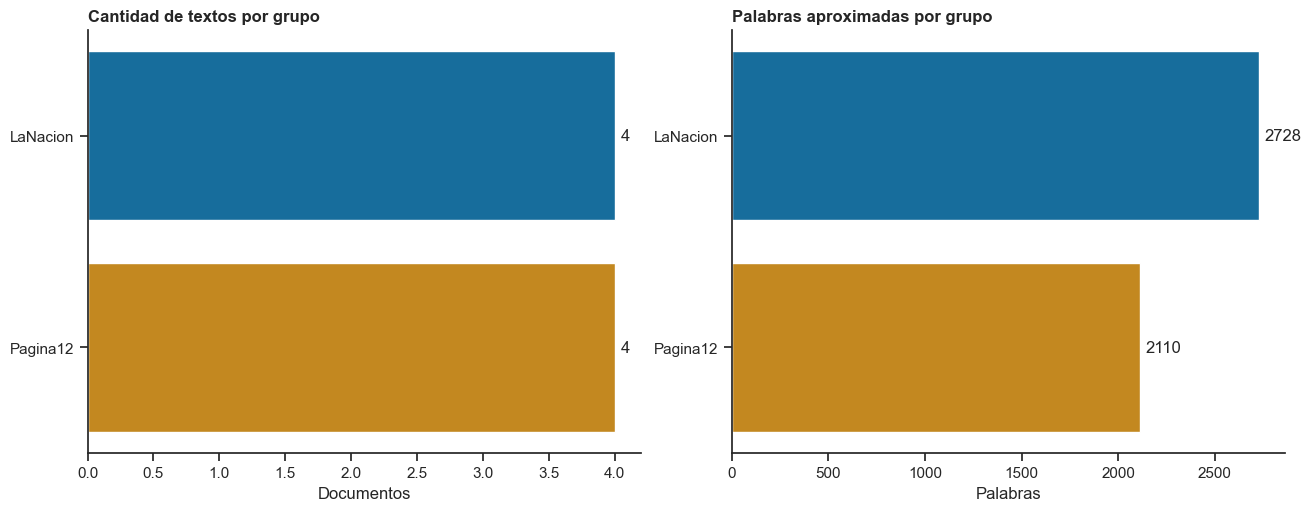

In [56]:
# Gráficos de comparación: cantidad de textos y palabras por grupo
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

# Panel izquierdo: cantidad de documentos
sns.barplot(
    data=resumen_por_grupo,
    x="documentos",
    y=COLUMNA_GRUPO,
    hue=COLUMNA_GRUPO,
    palette="colorblind",
    legend=False,
    ax=axes[0],
)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.0f", padding=4)
axes[0].set_title("Cantidad de textos por grupo", loc="left", fontweight="bold")
axes[0].set_xlabel("Documentos")
axes[0].set_ylabel("")
sns.despine(ax=axes[0])

# Panel derecho: palabras totales
sns.barplot(
    data=resumen_por_grupo,
    x="palabras_totales",
    y=COLUMNA_GRUPO,
    hue=COLUMNA_GRUPO,
    palette="colorblind",
    legend=False,
    ax=axes[1],
)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.0f", padding=4)
axes[1].set_title("Palabras aproximadas por grupo", loc="left", fontweight="bold")
axes[1].set_xlabel("Palabras")
axes[1].set_ylabel("")
sns.despine(ax=axes[1])

plt.show()


**Pausa de lectura**

Miren estas tablas y gráficos como una auditoría del recorte. Si un grupo tiene mucha más longitud o muchas más piezas que el otro, anótenlo ahora: ese desbalance condiciona lo que después van a interpretar.


## 6. Procesamiento lingüístico con spaCy

Ahora vamos a construir una capa intermedia de observables: lemas, palabras de contenido y entidades nombradas. No alcanza para interpretar por sí sola, pero sí ordena mejor el corpus para mirar recurrencias y contrastes.


In [57]:
# Cargamos el modelo de spaCy
try:
    import spacy
    nlp = spacy.load(MODELO_SPACY)
    print(f"Modelo cargado correctamente: {MODELO_SPACY}")
except Exception as error:
    raise RuntimeError(
        "No se pudo cargar spaCy. Instalá el modelo con "
        "`python -m spacy download es_core_news_sm` y volvé a correr el cuaderno."
    ) from error


Modelo cargado correctamente: es_core_news_sm


In [58]:
def normalizar_lemma(token):
    """Obtiene el lema limpio de un token spaCy.
    Si el lema es vacío o el pronombre genérico, usa la forma original."""
    lema = token.lemma_.strip().lower()
    if not lema or lema == "-pron-":
        lema = token.text.lower()
    return lema


# --- Procesamos cada texto con spaCy ---
registros_linguisticos = []
for doc in nlp.pipe(df[COLUMNA_TEXTO].tolist(), batch_size=8):
    lemas = []
    contenido = []
    entidades = []

    for token in doc:
        if token.is_space:
            continue
        lema = normalizar_lemma(token)
        lemas.append(lema)
        # Solo palabras alfabéticas que no sean stopwords
        if token.is_alpha and not token.is_stop:
            contenido.append(lema)

    # Extraemos entidades nombradas (personas, organizaciones, lugares)
    for entidad in doc.ents:
        entidades.append({"texto": entidad.text, "etiqueta": entidad.label_})

    registros_linguisticos.append({
        "texto_lemas": " ".join(lemas),
        "texto_contenido": " ".join(contenido),
        "entidades": entidades,
    })

# Unimos los resultados al DataFrame principal
df_linguistico = pd.DataFrame(registros_linguisticos)
df = pd.concat([df.reset_index(drop=True), df_linguistico], axis=1)

display(df[["titulo", COLUMNA_GRUPO, "texto_contenido"]].head())


,titulo,grupo_comparacion,texto_contenido
0,Juan Carlos de Pablo analizó la inflación de marzo y advirtió por un dato “ausente” que puede impactar en los próximos meses,LaNacion,conocer él inflación marzo economista juan carlos pablo analizar dato variable explicar aumento ipc advertir presencia factor ausente ci...
1,"La inflación mayorista dio un salto en marzo y cerró en 3,4%",LaNacion,registrar febrero nivel mayo inflación mayorista salto marzo cerrar cifra arrojar minorista mes cortar proceso desaceleración empezar in...
2,"Sin carne, combustibles y tarifas, la inflación igual aceleró y encontró un nuevo piso",LaNacion,inflación marzo mensaje incómodo gobierno impacto transitorio guerra oriente mes consecutivo desaceleración distinto informe privado coi...
3,Juan Carlos de Pablo opinó sobre la inflación de marzo y explicó en detalle el impacto de la guerra de Medio Oriente en los precios,LaNacion,medición índice precio consumidor tercer mes año arrojar suba superior registro previo contexto economista juan carlos pablo diálogo exa...
4,"La inflación de marzo fue de 3,4 segun el INDEC",Pagina12,instituto nacional estadística censos indec inflación marzo índice precios consumidor ipc aumentar interanual mes consecutivo bajar aume...


## 7. Observables iniciales: términos, entidades y bigramas

Acá empieza la lectura distante. La pregunta no es todavía "qué significa el corpus", sino "qué regularidades o contrastes aparecen cuando cambiamos de escala".


In [59]:
def obtener_top_terminos_por_grupo(dataframe, top_n=10):
    """Cuenta los términos de contenido en cada grupo
    y devuelve los top_n más frecuentes por grupo."""
    registros = []
    for grupo, subconjunto in dataframe.groupby(COLUMNA_GRUPO):
        contador = Counter(" ".join(subconjunto["texto_contenido"]).split())
        for termino, frecuencia in contador.most_common(top_n):
            registros.append({
                "grupo": grupo,
                "término": termino,
                "frecuencia": frecuencia,
            })
    return pd.DataFrame(registros)


top_terminos = obtener_top_terminos_por_grupo(df, top_n=TOP_N)
display(top_terminos)


,grupo,término,frecuencia
0,LaNacion,inflación,36
1,LaNacion,precio,25
2,LaNacion,marzo,22
3,LaNacion,mes,18
4,LaNacion,dato,15
5,LaNacion,carne,14
6,LaNacion,tasa,12
7,LaNacion,producto,12
8,LaNacion,economista,10
9,LaNacion,guerra,10


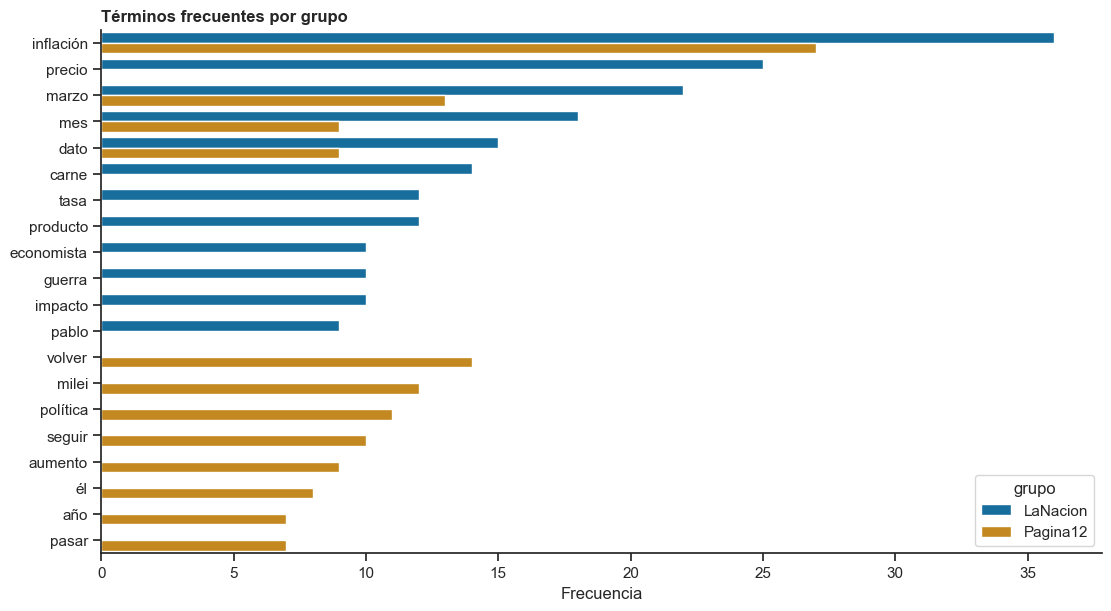

In [60]:
# Gráfico comparativo: términos frecuentes por grupo
fig, ax = plt.subplots(figsize=(11, 6), constrained_layout=True)
sns.barplot(
    data=top_terminos,
    x="frecuencia",
    y="término",
    hue="grupo",
    ax=ax,
)
ax.set_title("Términos frecuentes por grupo", loc="left", fontweight="bold")
ax.set_xlabel("Frecuencia")
ax.set_ylabel("")
sns.despine(ax=ax)
plt.show()


In [61]:
# --- Entidades nombradas por grupo ---
# Desagregamos las entidades documento por documento
registros_entidades = []
for fila in df.itertuples(index=False):
    for entidad in fila.entidades:
        registros_entidades.append({
            "grupo": getattr(fila, COLUMNA_GRUPO),
            "texto_entidad": entidad["texto"],
            "etiqueta": entidad["etiqueta"],
        })

df_entidades = pd.DataFrame(registros_entidades)

if not df_entidades.empty:
    # Agrupamos por grupo + texto + etiqueta, contamos y ordenamos
    top_entidades = (
        df_entidades.groupby(["grupo", "texto_entidad", "etiqueta"])
        .size()
        .reset_index(name="frecuencia")
        .sort_values(["grupo", "frecuencia"], ascending=[True, False])
    )
    display(top_entidades.head(TOP_N * 2))
else:
    top_entidades = pd.DataFrame(columns=["grupo", "texto_entidad", "etiqueta", "frecuencia"])
    print("No se detectaron entidades suficientes para armar una tabla de trabajo.")


,grupo,texto_entidad,etiqueta,frecuencia
45,LaNacion,IPC,MISC,6
48,LaNacion,Indec,LOC,6
44,LaNacion,Gobierno,LOC,5
96,LaNacion,año,MISC,5
101,LaNacion,la Argentina,LOC,5
68,LaNacion,Medio Oriente,MISC,4
13,LaNacion,BCRA,ORG,3
16,LaNacion,De Pablo,PER,3
52,LaNacion,Javier Milei,PER,3
53,LaNacion,Juan Carlos de Pablo,PER,3


In [62]:
# --- Bigramas por grupo ---
# Vectorizamos con bigramas (ngram_range=(2,2)) sobre el texto de contenido
vectorizador_bigramas = CountVectorizer(lowercase=False, ngram_range=(2, 2), min_df=1)
matriz_bigramas = vectorizador_bigramas.fit_transform(df["texto_contenido"])

# Convertimos a DataFrame con títulos como índice
tabla_bigramas = pd.DataFrame(
    matriz_bigramas.toarray(),
    index=df["titulo"],
    columns=vectorizador_bigramas.get_feature_names_out(),
)

# Sumamos bigramas dentro de cada grupo
bigramas_por_grupo = (
    tabla_bigramas.assign(grupo=df[COLUMNA_GRUPO].values)
    .groupby("grupo")
    .sum()
    .T
)

# Extraemos los top_n bigramas de cada grupo
registros_bigramas = []
for grupo in bigramas_por_grupo.columns:
    top = bigramas_por_grupo[grupo].sort_values(ascending=False).head(TOP_N)
    for bigrama, frecuencia in top.items():
        registros_bigramas.append({
            "grupo": grupo,
            "bigrama": bigrama,
            "frecuencia": int(frecuencia),
        })

top_bigramas = pd.DataFrame(registros_bigramas)
display(top_bigramas)


,grupo,bigrama,frecuencia
0,LaNacion,tasa inflación,6
1,LaNacion,inflación marzo,5
2,LaNacion,inflación mayorista,5
3,LaNacion,inflación núcleo,5
4,LaNacion,índice precio,4
5,LaNacion,dato inflación,4
6,LaNacion,producto nacional,4
7,LaNacion,elemento duro,4
8,LaNacion,precio mayorista,3
9,LaNacion,producto primario,3


**Pausa de lectura**

Hasta acá no alcanza con decir "este grupo usa más tal palabra". Anoten qué términos, entidades o asociaciones parecen organizar mejor cada serie y cuáles todavía necesitan volver al texto para no sobredimensionar la frecuencia.


## 8. Bag of Words y TF-IDF

En esta sección el contraste ya no es solo documento por documento. Vamos a reunir los textos de cada grupo para ver qué vocabulario aparece con fuerza y qué términos resultan más distintivos en cada serie.


In [63]:
# Concatenamos todos los textos de contenido de cada grupo en un solo string
corpus_por_grupo = (
    df.groupby(COLUMNA_GRUPO, as_index=False)
    .agg(texto_modelo=("texto_contenido", " ".join))
    .rename(columns={COLUMNA_GRUPO: "grupo"})
)

display(corpus_por_grupo)


,grupo,texto_modelo
0,LaNacion,conocer él inflación marzo economista juan carlos pablo analizar dato variable explicar aumento ipc advertir presencia factor ausente ci...
1,Pagina12,instituto nacional estadística censos indec inflación marzo índice precios consumidor ipc aumentar interanual mes consecutivo bajar aume...


In [64]:
# --- Funciones auxiliares para BoW y TF-IDF ---

def matriz_a_dataframe(matriz, nombres_columnas, nombres_filas):
    """Convierte una matriz sparse en un DataFrame legible."""
    return pd.DataFrame(matriz.toarray(), columns=nombres_columnas, index=nombres_filas)


def extraer_top_por_grupo(tabla_matriz, top_n=10, nombre_valor="valor"):
    """Para cada grupo (fila), extrae los top_n términos con mayor valor."""
    registros = []
    for grupo, serie in tabla_matriz.iterrows():
        # Filtramos valores > 0, ordenamos de mayor a menor
        top = serie[serie > 0].sort_values(ascending=False).head(top_n)
        for termino, valor in top.items():
            registros.append({
                "grupo": grupo,
                "término": termino,
                nombre_valor: round(float(valor), 4),
            })
    return pd.DataFrame(registros)


# --- Bag of Words ---
# max_df=0.95 descarta términos que aparecen en >95% de los documentos
vectorizador_bow = CountVectorizer(lowercase=False, min_df=MIN_DF, max_df=MAX_DF)
matriz_bow = vectorizador_bow.fit_transform(corpus_por_grupo["texto_modelo"])
tabla_bow = matriz_a_dataframe(matriz_bow, vectorizador_bow.get_feature_names_out(), corpus_por_grupo["grupo"])
top_bow = extraer_top_por_grupo(tabla_bow, top_n=TOP_N, nombre_valor="frecuencia")

# --- TF-IDF ---
vectorizador_tfidf = TfidfVectorizer(lowercase=False, min_df=MIN_DF, max_df=MAX_DF)
matriz_tfidf = vectorizador_tfidf.fit_transform(corpus_por_grupo["texto_modelo"])
tabla_tfidf = matriz_a_dataframe(matriz_tfidf, vectorizador_tfidf.get_feature_names_out(), corpus_por_grupo["grupo"])
top_tfidf = extraer_top_por_grupo(tabla_tfidf, top_n=TOP_N, nombre_valor="tfidf")

# --- Mostramos ambas tablas ---
print("Top de términos según Bag of Words")
display(top_bow)
print("Top de términos según TF-IDF")
display(top_tfidf)


Top de términos según Bag of Words


,grupo,término,frecuencia
0,LaNacion,producto,12.0
1,LaNacion,petróleo,9.0
2,LaNacion,pablo,9.0
3,LaNacion,mayorista,8.0
4,LaNacion,alimento,8.0
5,LaNacion,bien,6.0
6,LaNacion,elemento,6.0
7,LaNacion,promedio,5.0
8,LaNacion,incluir,5.0
9,LaNacion,informe,5.0


Top de términos según TF-IDF


,grupo,término,tfidf
0,LaNacion,producto,0.2852
1,LaNacion,petróleo,0.2139
2,LaNacion,pablo,0.2139
3,LaNacion,mayorista,0.1902
4,LaNacion,alimento,0.1902
5,LaNacion,bien,0.1426
6,LaNacion,elemento,0.1426
7,LaNacion,promedio,0.1188
8,LaNacion,incluir,0.1188
9,LaNacion,informe,0.1188


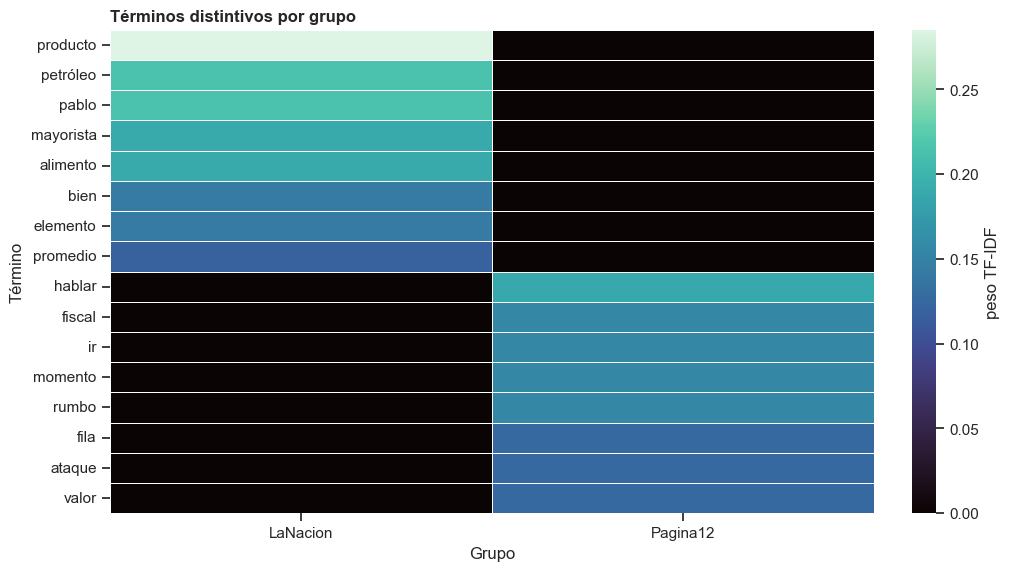

In [65]:
# Mapa de calor: términos distintivos por grupo
# Seleccionamos los top-8 términos TF-IDF de cada grupo (sin repetir)
terminos_heatmap = list(dict.fromkeys(
    top_tfidf.groupby("grupo").head(8)["término"].tolist()
))
matriz_heatmap = tabla_tfidf[terminos_heatmap].T

fig, ax = plt.subplots(
    figsize=(10, max(4, len(terminos_heatmap) * 0.35)),
    constrained_layout=True,
)
sns.heatmap(
    matriz_heatmap,
    cmap="mako",
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "peso TF-IDF"},
    ax=ax,
)
ax.set_title("Términos distintivos por grupo", loc="left", fontweight="bold")
ax.set_xlabel("Grupo")
ax.set_ylabel("Término")
plt.show()


**Pausa de lectura**

Acá conviene comparar dos cosas:

- qué términos son frecuentes en ambos grupos;
- qué términos no necesariamente son los más frecuentes, pero sí los más distintivos según `TF-IDF`.

No confundan volumen con especificidad. Esa diferencia es central en este trabajo.


## 9. Del patrón al fragmento

La lectura distante orienta. La lectura cercana confirma, corrige o complejiza. Ahora vamos a elegir algunos términos distintivos y a volver a los textos para ver cómo aparecen en contexto.


In [66]:
# Tomamos los 2 términos más distintivos de cada grupo
terminos_para_volver = top_tfidf.groupby("grupo").head(2).reset_index(drop=True)
display(terminos_para_volver)


,grupo,término,tfidf
0,LaNacion,producto,0.2852
1,LaNacion,petróleo,0.2139
2,Pagina12,hablar,0.1876
3,Pagina12,fiscal,0.1563


In [67]:
def extraer_fragmentos(dataframe, grupo, termino, columna_texto="texto", ventana=140, max_fragmentos=3):
    """Busca un término en los textos originales de un grupo y devuelve
    hasta max_fragmentos centrados en la primera aparición de cada texto."""
    patron = re.compile(rf"\b{re.escape(termino)}\b", flags=re.IGNORECASE)
    registros = []
    subconjunto = dataframe[dataframe[COLUMNA_GRUPO] == grupo]

    for fila in subconjunto.itertuples(index=False):
        texto = getattr(fila, columna_texto)
        coincidencia = patron.search(texto)
        if not coincidencia:
            continue

        # Recortamos una ventana alrededor de la primera aparición
        inicio = max(0, coincidencia.start() - ventana)
        fin = min(len(texto), coincidencia.end() + ventana)
        fragmento = texto[inicio:fin].strip()

        # Agregamos "..." si el fragmento no empieza/termina con el texto completo
        if inicio > 0:
            fragmento = "..." + fragmento
        if fin < len(texto):
            fragmento = fragmento + "..."

        registros.append({
            "grupo": grupo,
            "término": termino,
            "título": fila.titulo,
            "fragmento": fragmento,
        })
        if len(registros) >= max_fragmentos:
            break
    return registros


# --- Buscamos los fragmentos para cada término distintivo ---
registros_fragmentos = []
for fila in terminos_para_volver.itertuples(index=False):
    registros_fragmentos.extend(
        extraer_fragmentos(
            df,
            grupo=fila.grupo,
            termino=fila.término,
            columna_texto=COLUMNA_TEXTO,
            ventana=VENTANA_FRAGMENTO,
            max_fragmentos=3,
        )
    )

fragmentos = pd.DataFrame(registros_fragmentos)
display(fragmentos)


,grupo,término,título,fragmento
0,LaNacion,petróleo,Juan Carlos de Pablo analizó la inflación de marzo y advirtió por un dato “ausente” que puede impactar en los próximos meses,"...os efectos directos de la guerra en Medio Oriente, como sí ocurrió en otros países, donde incidió en los precios a raíz de la variaci..."
1,LaNacion,petróleo,"La inflación mayorista dio un salto en marzo y cerró en 3,4%","...or un combo de bienes y servicios –además, medidos a nivel consumidor final–. En el aumento de los productos nacionales se destacó el..."
2,LaNacion,petróleo,Juan Carlos de Pablo opinó sobre la inflación de marzo y explicó en detalle el impacto de la guerra de Medio Oriente en los precios,"...conomista sostuvo que Argentina aún no sintió los efectos directos del enfrentamiento armado, pero otros países sufrieron variaciones..."
3,Pagina12,hablar,"Milei, con la brújula rota: “No es inflación, es un salto de precios”","...a que no se pueda acercar a los funcionarios, Milei ingresó al escenario del evento pasadas las seis de la tarde. Allí comenzó sin ro..."
4,Pagina12,hablar,La eterna promesa de Milei: “Tarde o temprano las cosas van a empezar a funcionar”,"...directa al dato inflacionario. Admitió que “no le gustó” e incluso dijo que le “repugna”, pero aclaró que no iba a esquivar el tema. ..."
5,Pagina12,fiscal,"Milei, con la brújula rota: “No es inflación, es un salto de precios”","...política, un ataque destituyente, un ataque al corazón del modelo donde en el Congreso pasó más de 40 leyes intentando romper el equi..."
6,Pagina12,fiscal,La eterna promesa de Milei: “Tarde o temprano las cosas van a empezar a funcionar”,"...plicar esos datos ni cómo se traducen en la vida cotidiana.,En paralelo, dejó en claro que no habrá cambios en el rumbo. Ratificó el ..."


## 10. Escritura interpretativa

Agreguen una o más celdas Markdown nuevas y respondan estas preguntas:

1. **Recorte y comparación**
   - ¿Qué comparan exactamente?
   - ¿Qué vuelve válidos esos dos grupos como contraste?

2. **Lectura distante**
   - ¿Qué términos, entidades o asociaciones lexicales organizan cada grupo?
   - ¿Qué diferencias aparecen con más claridad cuando miran `TF-IDF` y no solo frecuencias?

3. **Lectura cercana**
   - ¿Cómo aparece en contexto al menos uno de los términos distintivos de cada grupo?
   - ¿Qué cambia cuando vuelven al fragmento?

4. **Visualización y método**
   - ¿Qué gráfico ayudó realmente a comprender mejor el contraste?
   - ¿Qué límites tiene este enfoque para leer discurso?
   - ¿Qué no se puede afirmar solo con estas representaciones sparse?


10. Escritura interpretativa
1. Recorte y comparación

En este trabajo se comparan dos conjuntos de textos periodísticos sobre inflación y coyuntura económica en Argentina, publicados por La Nación y Página/12. El objetivo del análisis fue observar cómo ambos medios construyen discursivamente un mismo fenómeno económico a partir de elecciones léxicas, asociaciones temáticas y marcos interpretativos diferentes.

La comparación resulta válida porque ambos grupos:

pertenecen al mismo género discursivo (noticia / nota periodística);
abordan un mismo tema central (inflación);
fueron publicados en un período cercano;
poseen una cantidad equilibrada de textos dentro del corpus;
presentan líneas editoriales distintas, lo que vuelve significativo el contraste discursivo.

Esto permite comparar no solamente el contenido, sino también la forma en que cada medio encuadra el fenómeno económico.

2. Lectura distante

El análisis cuantitativo muestra diferencias claras entre ambos medios.

En el corpus de La Nación aparecen con mayor frecuencia términos como:

producto
petróleo
mayorista
alimento
energía
tasa
carne

Estos términos construyen un campo semántico fuertemente ligado a variables económicas concretas, como costos, precios mayoristas, insumos productivos y factores externos que impactan sobre la inflación. La presencia recurrente de palabras como petróleo o energía sugiere una explicación centrada en causas estructurales y dinámicas de mercado.

En cambio, en Página/12 predominan términos como:

hablar
fiscal
rumbo
ataque
gabinete
política
milei

Aquí aparece un vocabulario más asociado a actores políticos, decisiones de gobierno y conflicto discursivo. La inflación no se presenta solamente como variable económica, sino también como consecuencia de una orientación política determinada.

Los bigramas refuerzan esta diferencia:

La Nación

tasa inflación
inflación mayorista
inflación núcleo
índice precio
producto nacional

Página/12

equilibrio fiscal
jefe gabinete
defender rumbo
política monetario
círculo rojo

Mientras el primer grupo enfatiza categorías técnicas y económicas, el segundo construye un marco interpretativo más político e ideológico.

3. Lectura cercana

La lectura contextual de fragmentos confirma los resultados cuantitativos.

En La Nación, términos distintivos como petróleo aparecen asociados a explicaciones sobre costos internacionales, energía, bienes primarios y presiones externas sobre los precios internos. La inflación es presentada como un fenómeno complejo, técnico y multicausal, vinculado a variables objetivables del sistema económico.

En Página/12, palabras como hablar o fiscal aparecen en contextos de declaraciones públicas, posicionamientos oficiales y debates sobre el rumbo económico. La inflación se inserta dentro de una narrativa más política, donde cobran relevancia las decisiones de gobierno, la confrontación discursiva y el modelo económico adoptado.

En consecuencia, ambos medios hablan del mismo fenómeno, pero lo interpretan desde marcos discursivos distintos:

La Nación → enfoque técnico / económico
Página/12 → enfoque político / interpretativo
4. Límites y decisiones metodológicas

Este análisis presenta algunas limitaciones:

el corpus es reducido (8 textos);
el recorte temporal es acotado;
ciertas palabras frecuentes responden a coyunturas puntuales;
el análisis textual no captura completamente tono, ironía o elementos visuales del discurso;
la eliminación manual de términos muy frecuentes (como ciento) mejora la limpieza léxica, pero también implica una decisión metodológica que puede influir en la representación final del corpus.

Sin embargo, la combinación de frecuencia léxica, análisis de bigramas, Bag of Words, TF-IDF, y lectura contextual de fragmentos permite construir una comparación sólida y argumentada sobre las diferencias discursivas entre ambos medios.

In [31]:
# --- Exportación opcional de tablas auxiliares ---
EXPORTAR_RESULTADOS = False
CARPETA_SALIDA = Path("salidas_tpi2")

if EXPORTAR_RESULTADOS:
    CARPETA_SALIDA.mkdir(exist_ok=True)
    resumen_corpus.to_csv(CARPETA_SALIDA / "resumen_corpus.csv", index=False)
    resumen_por_grupo.to_csv(CARPETA_SALIDA / "resumen_por_grupo.csv", index=False)
    top_terminos.to_csv(CARPETA_SALIDA / "top_terminos_por_grupo.csv", index=False)
    top_entidades.to_csv(CARPETA_SALIDA / "top_entidades.csv", index=False)
    top_bigramas.to_csv(CARPETA_SALIDA / "top_bigramas.csv", index=False)
    top_bow.to_csv(CARPETA_SALIDA / "top_bow.csv", index=False)
    top_tfidf.to_csv(CARPETA_SALIDA / "top_tfidf.csv", index=False)
    fragmentos.to_csv(CARPETA_SALIDA / "fragmentos.csv", index=False)
    print(f"Se exportaron archivos en {CARPETA_SALIDA.resolve()}")
else:
    print("Exportación desactivada. Si quieren guardar tablas auxiliares, cambien EXPORTAR_RESULTADOS a True.")


Exportación desactivada. Si quieren guardar tablas auxiliares, cambien EXPORTAR_RESULTADOS a True.


## 11. Checklist final de entrega

Antes de entregar, revisen esto:

- ¿El corpus tiene entre 6 y 10 textos y exactamente dos grupos comparables?
- ¿La columna `grupo_comparacion` está completa y bien usada?
- ¿Usaron `spaCy`, `Bag of Words`, `TF-IDF` y al menos una lectura de bigramas?
- ¿Incluyeron al menos dos visualizaciones analíticas legibles?
- ¿Volvieron al menos a tres fragmentos concretos?
- ¿Hay una interpretación final y una sección explícita de límites?
- ¿El notebook corre de principio a fin sin depender de ediciones manuales intermedias?

Si pueden responder que sí a todo, la entrega ya tiene la estructura mínima esperada para el TPI 2.
